# **CUSTOMER CHURN PREDICTION**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import  GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## **Feature Engineering**

In [ ]:
data.shape

(7043, 21)

In [ ]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


**Deleting Irrelevant Columns**

In [ ]:
data.drop(columns = ['customerID'], inplace = True)

**Converting Categorical Columns to Numerical Columns**

In [ ]:
column_1 = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in column_1:
  data[col] = data[col].map({'Yes' : 1, 'No' : 0})

In [ ]:
column_2 = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in column_2:
  data[col] = data[col].map({'Yes' : 1, 'No' : 0, 'No internet service' : 0})

In [ ]:
data = pd.get_dummies(data, columns = ['InternetService', 'PaymentMethod', 'Contract'], drop_first = True, dtype = int)

In [ ]:
data['MultipleLines'] = data['MultipleLines'].map({'No phone service' : 0, 'No' : 0, 'Yes' : 1})

In [ ]:
data['gender'] = data['gender'].map({'Female' : 0, 'Male' : 1})

**Converting Total Charges column (object) but actually numerical to Numerical Columns**



In [ ]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors = 'coerce')

In [ ]:
data.dtypes

,0
gender,int64
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64


**Checking for Missing Values and Duplicate Records**

In [ ]:
data.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
OnlineSecurity,0
OnlineBackup,0
DeviceProtection,0


In [ ]:
data.duplicated().sum()

np.int64(22)

**Dropping the Duplicate Records**

In [ ]:
data.drop_duplicates(inplace = True)

**Imputing Missing values**

In [ ]:
data[data.isnull().any(axis=1)]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Contract_One year,Contract_Two year
488,0,0,1,1,0,0,0,1,0,1,...,52.55,NaN,0,0,0,0,0,0,0,1
753,1,0,0,1,0,1,0,0,0,0,...,20.25,NaN,0,0,1,0,0,1,0,1
936,0,0,1,1,0,1,0,1,1,1,...,80.85,NaN,0,0,0,0,0,1,0,1
1082,1,0,1,1,0,1,1,0,0,0,...,25.75,NaN,0,0,1,0,0,1,0,1
1340,0,0,1,1,0,0,0,1,1,1,...,56.05,NaN,0,0,0,1,0,0,0,1
3331,1,0,1,1,0,1,0,0,0,0,...,19.85,NaN,0,0,1,0,0,1,0,1
3826,1,0,1,1,0,1,1,0,0,0,...,25.35,NaN,0,0,1,0,0,1,0,1
4380,0,0,1,1,0,1,0,0,0,0,...,20.00,NaN,0,0,1,0,0,1,0,1
5218,1,0,1,1,0,1,0,0,0,0,...,19.70,NaN,0,0,1,0,0,1,1,0
6670,0,0,1,1,0,1,1,0,1,1,...,73.35,NaN,0,0,0,0,0,1,0,1


###### **--->** Missing values correspond to customers with zero tenure considering that they are new users.

In [ ]:
data['TotalCharges'].fillna(0, inplace = True)

**Which features affect churn?**

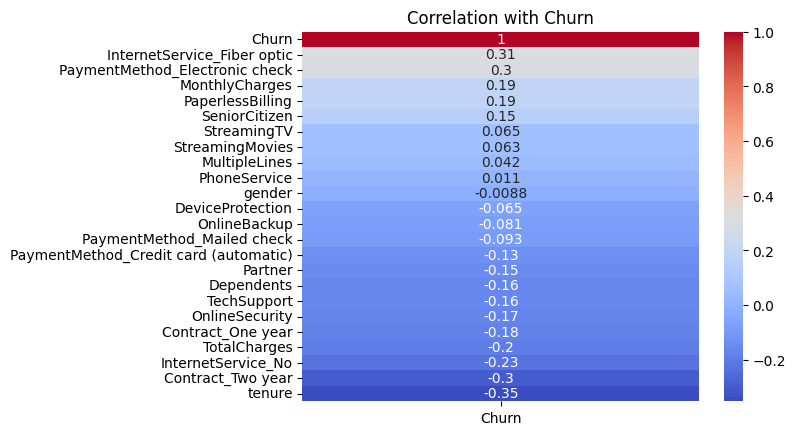

In [ ]:
sns.heatmap(
    data.corr()[['Churn']].sort_values(by='Churn', ascending=False),
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation with Churn')
plt.show()

###### **-->** Strong Negative correlation → feature decreases with churn
**1.   Contract**
**2.   Tenure**
**3.   InternetService_No**
**4.   TotalCharges**

###### **-->** Strong Positive correlation → feature increases with churn
**1.   InternetService_Fiber optic**
**2.   PaymentMethod_Electronic check**
**3.   MonthlyCharges**
**4.   PaperlessBilling**
**5.   SeniorCitizen**










**FINAL FEATURES TO KEEP**
1.   Contract
2.   tenure
3.   MonthlyCharges
4.   InternetService_Fiber optic
5.   InternetService_No
6.   PaymentMethod_Electronic check
7.   PaperlessBilling
8.   SeniorCitizen
9.   OnlineSecurity
10.  StreamingTV

**FINAL FEATURES TO DROP**



1.   TotalCharges (highly correlated with tenure & MonthlyCharges)
2.   gender (very weak effect)
3.   PhoneService
4.   MultipleLines
5.   StreamingMovies (redundant)
6.   TechSupport (redundant)














**Dropping the Correlated Features**
###### **--->** TotalCharges was removed due to high correlation with tenure and MonthlyCharges to avoid redundancy.

In [ ]:
data.drop(columns = ['TotalCharges','PhoneService','MultipleLines','StreamingMovies','TechSupport','gender','Dependents', 'Partner', 'SeniorCitizen'], inplace = True)

In [ ]:
data.shape

(7021, 15)

**Creating Independent and Dependent Variable**

In [ ]:
x = data.drop(columns = ['Churn'], axis = 1)
y = data['Churn']

**Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 1, stratify = y)

**Feature Scaling**

**--->** To avoid data leakage, I fitted the scaler only on training data and used the same transformation on the test set.

In [ ]:
scaler = StandardScaler()
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [ ]:
scaler_min = MinMaxScaler()
x_train_min = scaler_min.fit_transform(X_train)
x_test_min = scaler_min.transform(X_test)

**Handling Imbalanced Data**

In [ ]:
smt = SMOTETomek(random_state = 1)
x_smt, y_smt = smt.fit_resample(x_train, y_train)
x_smt_min, y_smt_min = smt.fit_resample(x_train_min, y_train)

### **Model Building and Evaluation**

**1. Logistic Regression**

**Learning**

In [ ]:
model_lr = LogisticRegression(max_iter = 1000, class_weight="balanced")
model_lr.fit(x_smt, y_smt)

LogisticRegression(class_weight='balanced', max_iter=1000)

**Predicting**

In [ ]:
y_predict_lr = model_lr.predict(x_test)

In [ ]:
y_prob_lr = model_lr.predict_proba(x_test)[:,1]

**Evaluating**

In [ ]:
cl_lr = classification_report(y_test,y_predict_lr, output_dict = True)
table_1  = pd.DataFrame(cl_lr).transpose()
table_1['Model'] = 'Logistic Regression'

In [ ]:
confusion_matrix(y_test, y_predict_lr)

array([[1118,  432],
       [ 114,  443]])

In [ ]:
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
recall_lr = recall_score(y_test, y_predict_lr)

**2. Random Forest**

**Learning**

In [ ]:
model_rf = RandomForestClassifier(n_estimators=500 , max_features = "log2", max_leaf_nodes = 30)
model_rf.fit(x_smt, y_smt)

RandomForestClassifier(max_features='log2', max_leaf_nodes=30, n_estimators=500)

**Predicting**

In [ ]:
y_predict_rf = model_rf.predict(x_test)

In [ ]:
y_prob_rf = model_rf.predict_proba(x_test)[:,1]

**Evaluating**

In [ ]:
cl_rf = classification_report(y_test,y_predict_rf, output_dict = True)
table_2  = pd.DataFrame(cl_rf).transpose()
table_2['Model'] = 'Random Forest'

In [ ]:
confusion_matrix(y_test, y_predict_rf)

array([[1125,  425],
       [ 115,  442]])

In [ ]:
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
recall_rf = recall_score(y_test, y_predict_rf)

**Hyperparameter Tuning**

In [ ]:
# param_grid = {
#     'n_estimators': [50, 100, 150, 200, 500],
#     'max_features': ['sqrt', 'log2', None],
#     'max_depth': [3, 6, 9],
#     'max_leaf_nodes': [3, 6, 9, 30],
# }

In [ ]:
# grid_search = GridSearchCV(RandomForestClassifier(),
#                            param_grid=param_grid)
# grid_search.fit(x_smt, y_smt)
# print(grid_search.best_estimator_)

**3. Adaboost Classifier**

**Learning**

In [ ]:
model_ab = AdaBoostClassifier()
model_ab.fit(x_smt, y_smt)

AdaBoostClassifier()

**Predicting**

In [ ]:
y_predict_ab = model_ab.predict(x_test)

In [ ]:
y_prob_ab = model_ab.predict_proba(x_test)[:,1]

**Evaluating**

In [ ]:
cl_ab = classification_report(y_test,y_predict_ab, output_dict = True)
table_3  = pd.DataFrame(cl_ab).transpose()
table_3['Model'] = 'AdaBoost Classifier'

In [ ]:
confusion_matrix(y_test, y_predict_ab)

array([[1101,  449],
       [ 116,  441]])

In [ ]:
roc_auc_ab = roc_auc_score(y_test, y_prob_ab)
recall_ab = recall_score(y_test, y_predict_ab)

**4. XGBoost Classifier**

**Learning**

In [ ]:
model_xg = XGBClassifier(eval_metric = "logloss")
model_xg.fit(x_smt, y_smt)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

**Predicting**

In [ ]:
y_predict_xg = model_xg.predict(x_test)

In [ ]:
y_prob_xg = model_xg.predict_proba(x_test)[:,1]

**Evaluating**

In [ ]:
cl_xg = classification_report(y_test,y_predict_xg, output_dict = True)
table_4  = pd.DataFrame(cl_xg).transpose()
table_4['Model'] = 'XGBoost Classifier'

In [ ]:
confusion_matrix(y_test, y_predict_xg)

array([[1231,  319],
       [ 183,  374]])

In [ ]:
roc_auc_xg = roc_auc_score(y_test, y_prob_xg)
recall_xg = recall_score(y_test, y_predict_xg)

**5. K Nearest Neighbors**

**Learning**

In [ ]:
model_knn = KNeighborsClassifier(n_neighbors = 11)
model_knn.fit(x_smt, y_smt)

KNeighborsClassifier(n_neighbors=11)

**Predicting**

In [ ]:
y_predict_knn = model_knn.predict(x_test)

In [ ]:
y_prob_knn = model_knn.predict_proba(x_test)[:,1]

**Evaluating**

In [ ]:
cl_knn = classification_report(y_test,y_predict_knn, output_dict = True)
table_5  = pd.DataFrame(cl_knn).transpose()
table_5['Model'] = 'KNearest Neighbor Classifier'

In [ ]:
confusion_matrix(y_test, y_predict_knn)

array([[1037,  513],
       [ 132,  425]])

In [ ]:
roc_auc_knn = roc_auc_score(y_test, y_prob_knn)
recall_knn = recall_score(y_test, y_predict_knn)

**---> Combined Classification Report of 5 models**

In [ ]:
table = pd.concat([table_1, table_2, table_3, table_4, table_5])
table

,precision,recall,f1-score,support,Model
0,0.907468,0.721290,0.803738,1550.000000,Logistic Regression
1,0.506286,0.795332,0.618715,557.000000,Logistic Regression
accuracy,0.740864,0.740864,0.740864,0.740864,Logistic Regression
macro avg,0.706877,0.758311,0.711227,2107.000000,Logistic Regression
weighted avg,0.801412,0.740864,0.754826,2107.000000,Logistic Regression
0,0.907258,0.725806,0.806452,1550.000000,Random Forest
1,0.509804,0.793537,0.620787,557.000000,Random Forest
accuracy,0.743711,0.743711,0.743711,0.743711,Random Forest
macro avg,0.708531,0.759672,0.713619,2107.000000,Random Forest
weighted avg,0.802188,0.743711,0.757370,2107.000000,Random Forest


**Combined recall and roc_auc of 5 models**

In [ ]:
rec_roc_auc = pd.DataFrame({'Models' : ['Logistic Regression', 'Random Forest', 'AdaBoost Classifier', 'XGBoost Claasifier', 'KNearest Neighbors'],
                            'Recall' : [recall_lr, recall_rf, recall_ab, recall_xg, recall_knn],
                            'ROC_AUC' : [roc_auc_lr, roc_auc_rf, roc_auc_ab, roc_auc_xg, roc_auc_knn]})
rec_roc_auc

,Models,Recall,ROC_AUC
0,Logistic Regression,0.795332,0.832900
1,Random Forest,0.793537,0.836272
2,AdaBoost Classifier,0.791741,0.832620
3,XGBoost Claasifier,0.671454,0.820136
4,KNearest Neighbors,0.763016,0.788238


**Based on the comparison of recall and ROC-AUC scores across models, Logistic Regression was selected as the final model for customer churn prediction, as it achieved the best balance between identifying churn customers and overall classification performance.**

**SHAP - Shapely Additive Explantions**

In [ ]:
x_smt_df = pd.DataFrame(x_smt, columns=x.columns)
x_test_df = pd.DataFrame(x_test, columns=x.columns)

In [ ]:
explainer = shap.LinearExplainer(model_lr, x_smt_df, feature_perturbation="interventional")

In [ ]:
shap_values = explainer.shap_values(x_test_df)

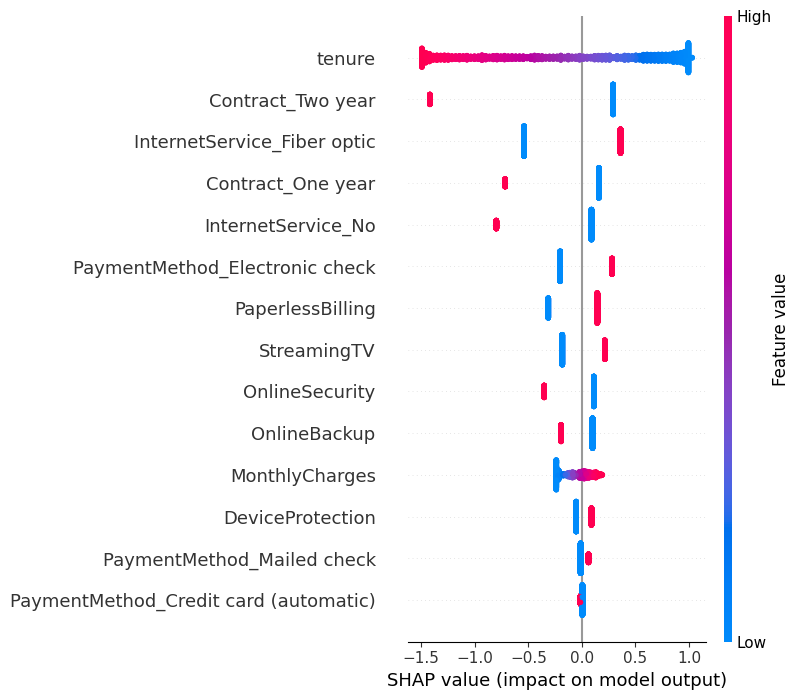

In [ ]:
shap.summary_plot(shap_values, x_test_df)

**Tenure (MOST IMPORTANT)**

1.   Low tenure (blue) → strong churn risk
2.   High tenure (red) → reduces churn

**Contract Type**

1.   Contract_Two year → strongly reduces churn
2.   Contract_One year → reduces churn
3.   Month-to-month customers → higher churn

**Internet Service (Fiber Optic)**


1.   Fiber optic customers churn more
Often due to higher price / service issues

**Online Security / Backup / Device Protection**

1.   Customers without these services churn more
2.   Add-on services increase stickiness

**Monthly Charges**


1.   Higher monthly charges → higher churn
Very common churn driver

**Payment Method**

1.   Electronic check → higher churn
2.   Automatic payments → lower churn
Shows behavioral churn patterns

**Demographics**


1.   Gender → negligible impact
2.   Senior citizen → moderate impact
3.   Dependents / Partner → stabilizing effect

**so I removed the Demographics from the features**

**RETENTION STRATEGY**

**Strategy 1: Contract Migration Campaign**


1.   SHAP Insight: Month-to-month customers churn more
2.   Action: Offer discounts for 1 - 2 year contracts

**Strategy 2: Early Tenure Protection**

1.   SHAP Insight: New customers churn most
2.   Action: Proactive onboarding & welcome offers

**Strategy 3: Service Bundling**

1.   SHAP Insight: No OnlineSecurity / Backup increases churn
2.   Action: Free trials for add-on services

**Strategy 4: High-Bill Alerts**

1.   SHAP Insight: High MonthlyCharges → churn
2.   Action: Personalized plan optimization

**Strategy 5: Payment Method Optimization**


1.   SHAP Insight: Electronic check users churn more
2.   Action: Incentivize auto-pay methods

**Saving Models**

**The trained Logistic Regression model (model_lr), the StandardScaler (scaler), and the feature names from the input variables (X) are saved for use during deployment and future predictions.**

In [ ]:
joblib.dump(model_lr, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(x.columns, "feature_columns.pkl")

['feature_columns.pkl']

In [ ]:
print(x.columns)

Index(['tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'StreamingTV', 'PaperlessBilling', 'MonthlyCharges',
       'InternetService_Fiber optic', 'InternetService_No',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_One year', 'Contract_Two year'],
      dtype='object')
